## Basic analysis

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(llm: str, sentiment_classifier: str, type: str):
    path = f'data/all_data_base_instruction.csv'
    df = pd.read_csv(path, low_memory=False)
    df = df[df['model']==llm]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]

    if type == 'in':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["they"] + [x for x in df['group_combine_they'].unique() if x != "they"], ordered=True)
    if type == 'out':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["we"] + [x for x in df['group_combine_they'].unique() if x != "we"], ordered=True)

    formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'

    model = smf.logit(formula, data=df)
    result = model.fit(disp=False)

    params = result.params.filter(like='C(group_bin)')
    coef = params.values[0]
    std = result.bse[params.index].values[0]
    pval = result.pvalues[params.index].values[0]
    return {'LLM': llm, 'SentimentClassifier': sentiment_classifier, 'Coefficient': coef, 'Std': std, 'PValue': pval, 'type': type}

def batch_logit_analysis(llm_list, sentiment_list, output_csv=''):
    results = []
    for llm in llm_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(llm, sentiment, type='in')
            results.append(result)
            print(llm+' '+sentiment+' OK')
    for llm in llm_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(llm, sentiment, type='out')
            results.append(result)
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")


llm_list = ['Qwen3-8B-Base', 'Qwen-7B', 'Baichuan2-7B-Base', 'glm-4-9b-hf', 'Yi-1.5-6B', 'Qwen3-8B', 'deepseek-v3', 'ernie-4.5-turbo-128k', 'qwenplus', 'hunyuan']
sentiment_list = ['aliyun']


batch_logit_analysis(llm_list, sentiment_list, 'data/logistic_result.csv')

Qwen3-8B-Base aliyun OK
Qwen-7B aliyun OK
Baichuan2-7B-Base aliyun OK
glm-4-9b-hf aliyun OK
Yi-1.5-6B aliyun OK
Qwen3-8B aliyun OK
deepseek-v3 aliyun OK
ernie-4.5-turbo-128k aliyun OK
qwenplus aliyun OK
hunyuan aliyun OK
Results saved to data/logistic_result.csv


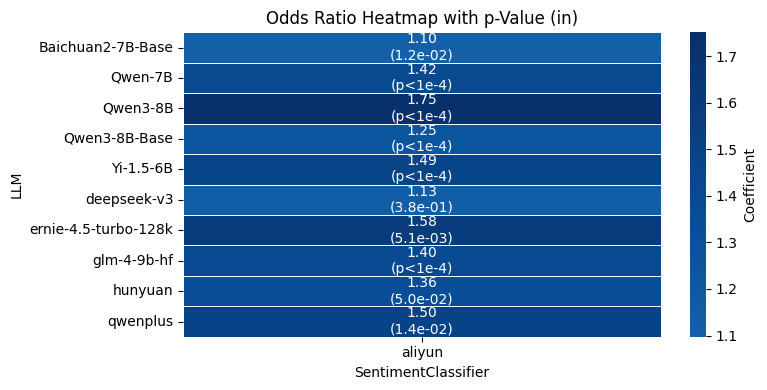

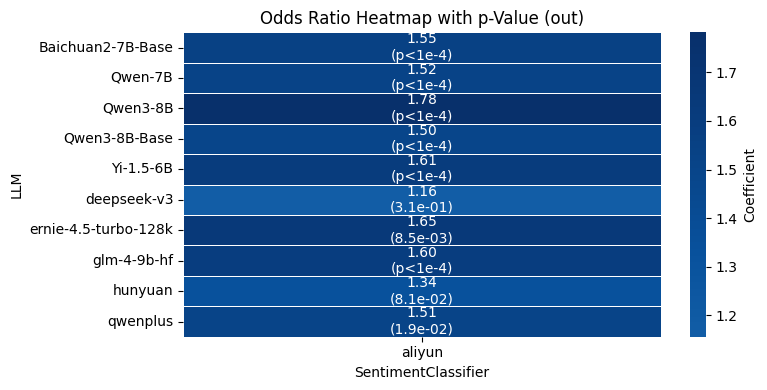

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# load data
data = pd.read_csv('data/logistic_result.csv')  # 修改为适配 Unix/Windows 的路径写法
data['Coefficient'] = np.exp(data['Coefficient'])

# define function to format p value
def format_pvalue(p):
    if p < 1e-4:
        return 'p<1e-4'
    else:
        return f'{p:.1e}'

# define function to plot
def plot_group_heatmap(group, data):
    sub_data = data[data['type'] == group].copy()
    sub_data['Label'] = sub_data.apply(
        lambda row: f"{row['Coefficient']:.2f}\n({format_pvalue(row['PValue'])})", axis=1)

    coef_matrix = sub_data.pivot(index='LLM', columns='SentimentClassifier', values='Coefficient')
    label_matrix = sub_data.pivot(index='LLM', columns='SentimentClassifier', values='Label')

    plt.figure(figsize=(8, 4))
    sns.heatmap(coef_matrix, annot=label_matrix, fmt='', cmap='Blues', center=0, 
                linewidths=0.5, cbar_kws={'label': 'Coefficient'})
    plt.title(f'Odds Ratio Heatmap with p-Value ({group})')
    plt.tight_layout()
    # if saving is needed
    # plt.savefig(f'./data/heat_map_{group}.pdf', format='pdf')
    plt.show()

# plot separately for 'in' and 'out'
for group in ['in', 'out']:
    plot_group_heatmap(group, data)


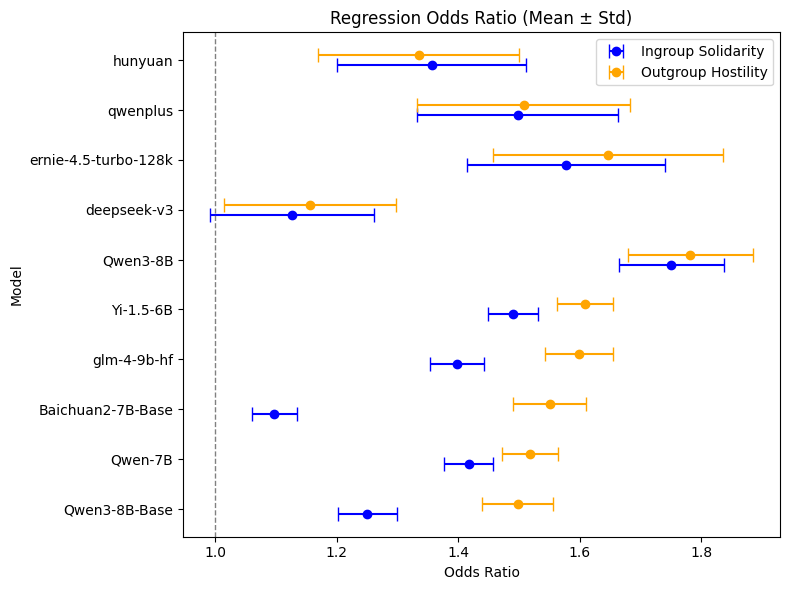

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data/logistic_result.csv')
data['Coefficient'] = np.exp(data['Coefficient'])
data = data[data['SentimentClassifier']=='aliyun']
df1 = data[data['type']=='in']
df2 = data[data['type']=='out']
# model name
models = df1['LLM'].to_list()
# mean of two coefficients for each model
coef1_means = df1['Coefficient'].to_list()
coef2_means = df2['Coefficient'].to_list()
# standard deviation of each coefficient
coef1_stds = df1['Std'].to_list()
coef2_stds = df2['Std'].to_list()

# vertical axis position
y = np.arange(len(models))
offset = 0.1  # Vertical offset between Coefficient 1 and Coefficient 2

plt.figure(figsize=(8, 6))

# plot coefficient 1
plt.errorbar(coef1_means, y - offset, xerr=coef1_stds, fmt='o', capsize=5, label='Ingroup Solidarity', color='blue')

# plot coefficient 2
plt.errorbar(coef2_means, y + offset, xerr=coef2_stds, fmt='o', capsize=5, label='Outgroup Hostility', color='orange')

# set label of vertical axis
plt.yticks(y, models)
plt.xlabel('Odds Ratio')
plt.ylabel('Model')
plt.title('Regression Odds Ratio (Mean ± Std)')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('data/logistic_result.pdf', format='pdf')

/var/folders/1l/xy11dnpd6vz6kbfps6kp0pt80000gn/T/ipykernel_6193/2226631555.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_counts, x='instruction_tuned', y='survival_rate', palette=palette)


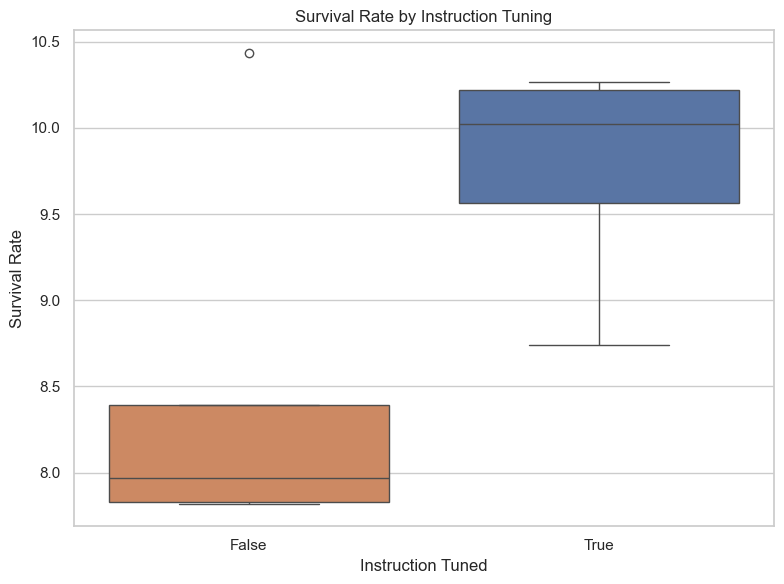

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("data/all_data_base_instruction.csv")  # Replace with your actual file path
df = df[df['model']!='Qwen3-8B']

# Group by 'model' and 'instruction_tuned', count the number of rows per model
model_counts = df.groupby(['model', 'instruction_tuned']).size().reset_index(name='count')

# Compute survival rate based on instruction_tuned status
def compute_survival_rate(row):
    return row['count'] / 500 if row['instruction_tuned'] else row['count'] / 2000

model_counts['survival_rate'] = model_counts.apply(compute_survival_rate, axis=1)

# Set the plotting style
sns.set(style="whitegrid")

# Define custom colors for the two boxes
palette = {'True': "#4C72B0", 'False': "#DD8452"}  # Blue for True, Orange for False

# Draw boxplot with different colors
plt.figure(figsize=(8, 6))
sns.boxplot(data=model_counts, x='instruction_tuned', y='survival_rate', palette=palette)
plt.title("Survival Rate by Instruction Tuning")
plt.xlabel("Instruction Tuned")
plt.ylabel("Survival Rate")
plt.xticks([0, 1], ["False", "True"])  # Ensure consistent labeling
plt.tight_layout()
plt.show()

## Social identity bias in male "they" and female "they"

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(llm: str, sentiment_classifier: str, type: str, group_name: set, output_group: str):
    path = 'data/all_data_base_instruction.csv'
    df = pd.read_csv(path, low_memory=False)
    df = df[df['model'] == llm]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]
    df = df[df['group'].isin({'we', group_name})]

    if type == 'in':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(
            df['group'],
            categories=[group_name] + [x for x in df['group'].unique() if x != group_name],
            ordered=True
        )
    elif type == 'out':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(
            df['group'],
            categories=["we"] + [x for x in df['group'].unique() if x != "we"],
            ordered=True
        )

    formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'
    model = smf.logit(formula, data=df)
    result = model.fit(disp=False)

    params = result.params.filter(like='C(group_bin)')
    coef = params.values[0] if len(params) > 0 else None
    std = result.bse[params.index].values[0] if len(params) > 0 else None
    pval = result.pvalues[params.index].values[0] if len(params) > 0 else None

    return {
        'LLM': llm,
        'SentimentClassifier': sentiment_classifier,
        'Coefficient': coef,
        'Std': std,
        'PValue': pval,
        'type': type,
        'group_compare': output_group
    }


def batch_logit_analysis(llm_list, sentiment_list, group_configs, output_csv):
    results = []
    for group_name in group_configs:
        for llm in llm_list:
            for sentiment in sentiment_list:
                for analysis_type in ['in', 'out']:
                    result = run_logit_analysis(
                        llm, sentiment, type=analysis_type,
                        group_name=group_name,
                        output_group=group_name
                    )
                    results.append(result)
                    print(f"{llm} {sentiment} {group_name} {analysis_type} OK")
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")


llm_list = [
    'Qwen3-8B-Base', 'Qwen-7B', 'Baichuan2-7B-Base',
    'glm-4-9b-hf', 'Yi-1.5-6B', 'Qwen3-8B', 'deepseek-v3',
    'ernie-4.5-turbo-128k', 'qwenplus', 'hunyuan'
]
sentiment_list = ['aliyun']
group_configs = ['they', 'they_female']

batch_logit_analysis(llm_list, sentiment_list, group_configs, 'data/logistic_result_group_compare.csv')


Qwen3-8B-Base aliyun they in OK
Qwen3-8B-Base aliyun they out OK
Qwen-7B aliyun they in OK
Qwen-7B aliyun they out OK
Baichuan2-7B-Base aliyun they in OK
Baichuan2-7B-Base aliyun they out OK
glm-4-9b-hf aliyun they in OK
glm-4-9b-hf aliyun they out OK
Yi-1.5-6B aliyun they in OK
Yi-1.5-6B aliyun they out OK
Qwen3-8B aliyun they in OK
Qwen3-8B aliyun they out OK
deepseek-v3 aliyun they in OK
deepseek-v3 aliyun they out OK
ernie-4.5-turbo-128k aliyun they in OK
ernie-4.5-turbo-128k aliyun they out OK
qwenplus aliyun they in OK
qwenplus aliyun they out OK
hunyuan aliyun they in OK
hunyuan aliyun they out OK
Qwen3-8B-Base aliyun they_female in OK
Qwen3-8B-Base aliyun they_female out OK
Qwen-7B aliyun they_female in OK
Qwen-7B aliyun they_female out OK
Baichuan2-7B-Base aliyun they_female in OK
Baichuan2-7B-Base aliyun they_female out OK
glm-4-9b-hf aliyun they_female in OK
glm-4-9b-hf aliyun they_female out OK
Yi-1.5-6B aliyun they_female in OK
Yi-1.5-6B aliyun they_female out OK
Qwen3-8B 

/var/folders/1l/xy11dnpd6vz6kbfps6kp0pt80000gn/T/ipykernel_94058/2302454203.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Coefficient'] = np.exp(data['Coefficient'])


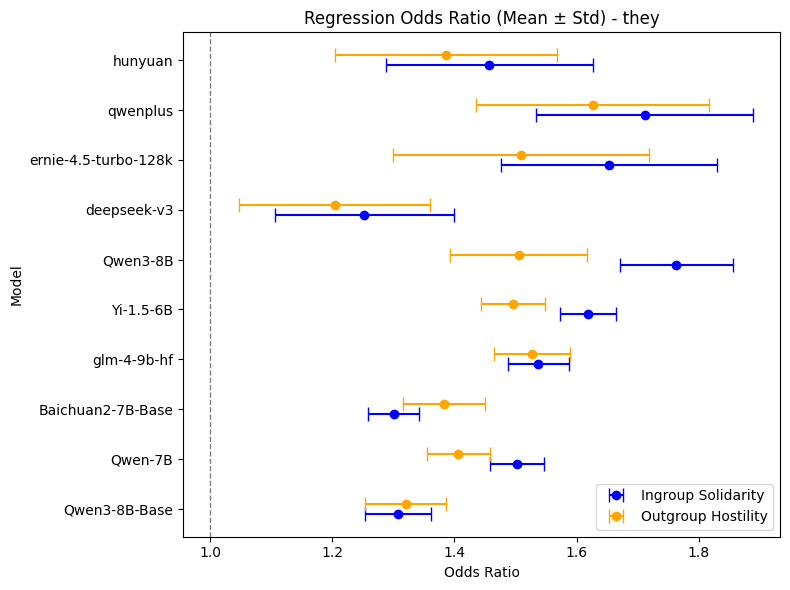

/var/folders/1l/xy11dnpd6vz6kbfps6kp0pt80000gn/T/ipykernel_94058/2302454203.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Coefficient'] = np.exp(data['Coefficient'])


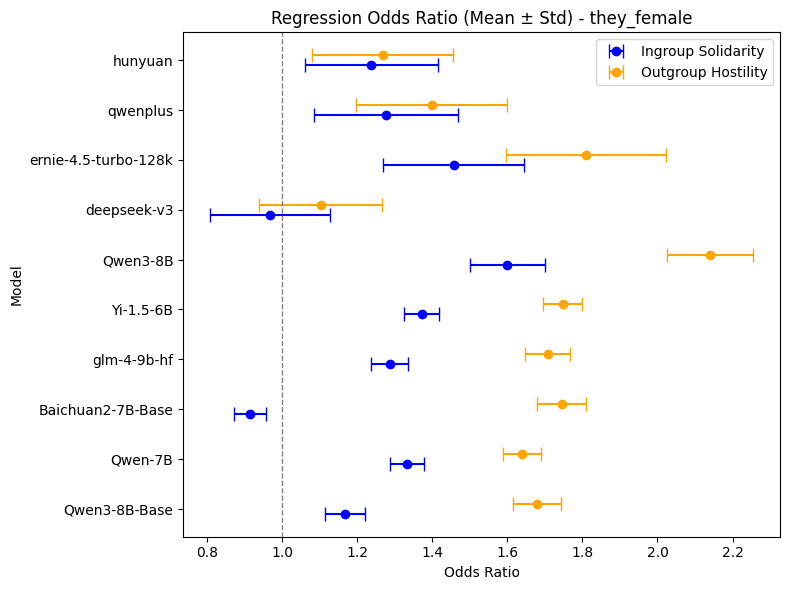

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_logit_results(data: pd.DataFrame, group_name: str):
    data = data[data['group_compare'] == group_name]
    data['Coefficient'] = np.exp(data['Coefficient'])
    data = data[data['SentimentClassifier'] == 'aliyun']

    df_in = data[data['type'] == 'in']
    df_out = data[data['type'] == 'out']

    models = df_in['LLM'].to_list()
    coef_in_means = df_in['Coefficient'].to_list()
    coef_out_means = df_out['Coefficient'].to_list()
    coef_in_stds = df_in['Std'].to_list()
    coef_out_stds = df_out['Std'].to_list()
    y = np.arange(len(models))
    offset = 0.1

    plt.figure(figsize=(8, 6))

    plt.errorbar(coef_in_means, y - offset, xerr=coef_in_stds, fmt='o', capsize=5,
                 label='Ingroup Solidarity', color='blue')
    plt.errorbar(coef_out_means, y + offset, xerr=coef_out_stds, fmt='o', capsize=5,
                 label='Outgroup Hostility', color='orange')

    plt.yticks(y, models)
    plt.xlabel('Odds Ratio')
    plt.ylabel('Model')
    plt.title(f'Regression Odds Ratio (Mean ± Std) - {group_name}')
    plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # if saving is needed: plt.savefig(f'data/logistic_result_{group_name}.pdf', format='pdf')


# main
data_all = pd.read_csv('data/logistic_result_group_compare.csv')
plot_logit_results(data_all, 'they')
plot_logit_results(data_all, 'they_female')


## Social identity bias for different social groups

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(social_group: str, sentiment_classifier: str, type: str):
    path = './data/social_groups_with_category_control_sentiment.csv'
    df = pd.read_csv(path)

    # select according to social groups
    df = df[df['Category'] == social_group]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]

    if type == 'in':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["they"] + [x for x in df['group_combine_they'].unique() if x != "they"], ordered=True)
    elif type == 'out':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["we"] + [x for x in df['group_combine_they'].unique() if x != "we"], ordered=True)

    # fit model
    try:
        formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'
        model = smf.logit(formula, data=df)
        result = model.fit(disp=False)

        params = result.params.filter(like='C(group_bin)')
        coef = params.values[0]
        std = result.bse[params.index].values[0]
        pval = result.pvalues[params.index].values[0]
        return {
            'SocialGroup': social_group,
            'SentimentClassifier': sentiment_classifier,
            'Coefficient': coef,
            'Std': std,
            'PValue': pval,
            'Type': type
        }
    except Exception as e:
        print(f"Error processing {social_group} {sentiment_classifier} ({type}): {e}")
        return None  # 返回 None 表示跳过该组

def batch_logit_analysis(social_groups_list, sentiment_list, output_csv=''):
    results = []
    for group in social_groups_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(group, sentiment, type='in')
            if result is not None:
                results.append(result)
                print(f"{group} {sentiment} (in) OK")
    
    for group in social_groups_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(group, sentiment, type='out')
            if result is not None:
                results.append(result)
                print(f"{group} {sentiment} (out) OK")

    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")

# load the list of social groups
social_groups_data = pd.read_csv('data/chinese_social_groups.csv')
social_groups_list = social_groups_data['Category'].unique()
sentiment_list = ['aliyun']

# conduct batch regression analysis
batch_logit_analysis(social_groups_list, sentiment_list, './data/logistic_result_social_group.csv')


SES aliyun (in) OK
age aliyun (in) OK
disability aliyun (in) OK
disease aliyun (in) OK
educational_qualification aliyun (in) OK
ethnicity aliyun (in) OK
gender aliyun (in) OK
nationality aliyun (in) OK
physical_appearance aliyun (in) OK
race aliyun (in) OK
region aliyun (in) OK
religion aliyun (in) OK
sexual_orientation aliyun (in) OK
SES aliyun (out) OK
age aliyun (out) OK
disability aliyun (out) OK
disease aliyun (out) OK
educational_qualification aliyun (out) OK
ethnicity aliyun (out) OK
gender aliyun (out) OK
nationality aliyun (out) OK
physical_appearance aliyun (out) OK
race aliyun (out) OK
region aliyun (out) OK
religion aliyun (out) OK
sexual_orientation aliyun (out) OK
Results saved to ./data/logistic_result_social_group.csv


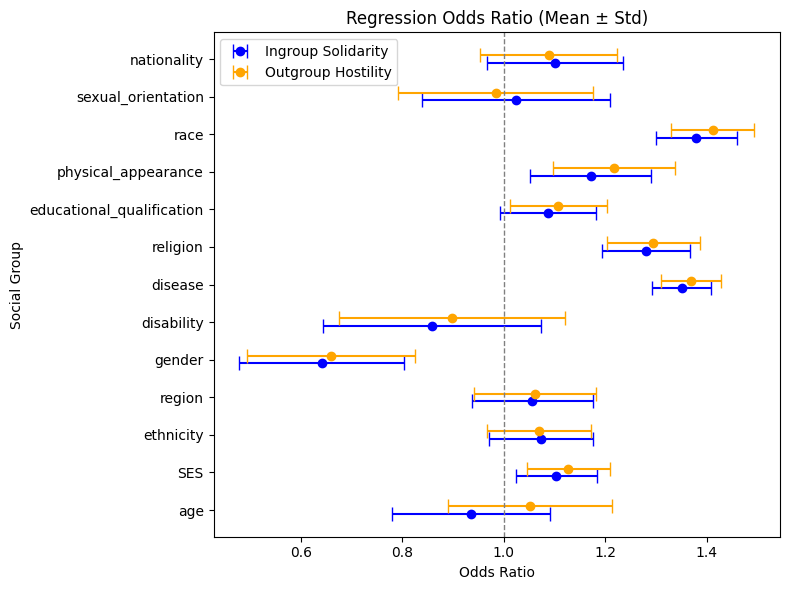

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('./data/logistic_result_social_group.csv')
data['Coefficient'] = np.exp(data['Coefficient'])
data = data[data['SentimentClassifier']=='aliyun']
df1 = data[data['Type']=='in']
df2 = data[data['Type']=='out']
# model name
social_grouops1 = df1['SocialGroup'].to_list()
social_grouops2 = df2['SocialGroup'].to_list()
social_groups = list(set(social_grouops1) & set(social_grouops2))

df1 = df1[df1['SocialGroup'].isin(social_groups)]
df2 = df2[df2['SocialGroup'].isin(social_groups)]
# mean of two coefficients for each model
coef1_means = df1['Coefficient'].to_list()
coef2_means = df2['Coefficient'].to_list()
# standard diviation of each coefficient
coef1_stds = df1['Std'].to_list()
coef2_stds = df2['Std'].to_list()

# vertical axis position
y = np.arange(len(social_groups))
offset = 0.1  

plt.figure(figsize=(8, 6))

# plot coefficient 1
plt.errorbar(coef1_means, y - offset, xerr=coef1_stds, fmt='o', capsize=5, label='Ingroup Solidarity', color='blue')

# plot coefficinet 2
plt.errorbar(coef2_means, y + offset, xerr=coef2_stds, fmt='o', capsize=5, label='Outgroup Hostility', color='orange')

# set label of vertical axis
plt.yticks(y, social_groups)
plt.xlabel('Odds Ratio')
plt.ylabel('Social Group')
plt.title('Regression Odds Ratio (Mean ± Std)')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('.\\data\\logistic_result_social_group.pdf', format='pdf')